In [5]:
import pandas as pd
import plotly.graph_objects as go

# ==========================================
# 1. SETTINGS & CONFIGURATION
# ==========================================
# --- FILE PATHS ---
# Update these to match your actual file locations
file_main        = "data/nextbike_data_VSB_Vaclavik.xlsx"
file_rebalancing = "data/nextbike_data_VSB_Vaclavik2.xlsx"

# SHEET NAMES
# Use the actual name (string) or index (0, 1) of the sheets
sheet_name_trips     = "Vypujcky_Ostrava"              # Usually the first sheet
sheet_name_snapshots = "Stanice_Ostrava"       # REPLACE with the actual name of the snapshot sheet

# STATION NAMES
# Must match the text in the Excel files exactly
station_trips    = 'SV-Svinov nádraží *(navíc 15min na odjezd)'
station_rebal    = 'SV-Svinov nádraží *(navíc 15min na odjezd)'

# --- INITIALIZATION ---
# Based on your first snapshot: 6 bikes at 00:05
start_time       = pd.Timestamp('2025-09-15 00:05:00')
initial_stock    = 6

# ==========================================
# 2. DATA LOADING
# ==========================================
print("Loading data files...")

# Load Trips
trips = pd.read_excel(file_main, sheet_name=sheet_name_trips)

# Load Snapshots (The Truth/Checksum)
snapshots = pd.read_excel(file_main, sheet_name=sheet_name_snapshots)

# Load Rebalancing
rebalancing = pd.read_excel(file_rebalancing)

# ==========================================
# 3. PROCESSING EVENTS
# ==========================================
print("Processing events...")

# --- A. Customer Departures (-1) ---
dept = trips[trips['start_place'] == station_trips].copy()
dept = dept[['start_time']].rename(columns={'start_time': 'timestamp'})
dept['change'] = -1

# --- B. Customer Arrivals (+1) ---
arr = trips[trips['end_place'] == station_trips].copy()
arr = arr[['end_time']].rename(columns={'end_time': 'timestamp'})
arr['change'] = 1

# --- C. Rebalancing Removals (Variable Negative) ---
# Note: Using the LONG station name here to match the rebalancing file
reb_dept = rebalancing[rebalancing['from'] == station_rebal].copy()
reb_dept = reb_dept[['timestamp', 'number_of_bikes']]
reb_dept['change'] = -1 * reb_dept['number_of_bikes'] # Flip sign to negative
reb_dept = reb_dept.drop(columns=['number_of_bikes'])

# --- D. Rebalancing Restocks (Variable Positive) ---
reb_arr = rebalancing[rebalancing['to'] == station_rebal].copy()
reb_arr = reb_arr[['timestamp', 'number_of_bikes']]
reb_arr['change'] = reb_arr['number_of_bikes'] # Keep positive
reb_arr = reb_arr.drop(columns=['number_of_bikes'])

# ==========================================
# 4. BUILDING THE TIMELINE
# ==========================================
print("Building continuous timeline...")

# 1. Merge all event lists into one
all_events = pd.concat([dept, arr, reb_dept, reb_arr])

# 2. Add the Starting Point (The Anchor)
start_row = pd.DataFrame([{'timestamp': start_time, 'change': initial_stock}])
timeline_events = pd.concat([start_row, all_events])

# 3. Sort Chronologically
timeline_events = timeline_events.sort_values('timestamp')

# 4. Calculate Running Total (The 'Stock')
# This gives us the count at the exact second an event happens
timeline_events['stock'] = timeline_events['change'].cumsum()

# 5. Resample to 1-Minute Intervals
# This creates the "Continuous" timeline you asked for
timeline_events = timeline_events.set_index('timestamp')
# 'last()' ensures we take the final count of the minute
final_timeline = timeline_events.resample('1min').agg({'stock': 'last'})
# 'ffill()' ensures empty minutes carry over the previous count
final_timeline = final_timeline.ffill().fillna(0)

# ==========================================
# 5. VALIDATION (CHECKSUM)
# ==========================================
print("Running validation against snapshots...")

# Prepare the Snapshot data (The "Truth")
checks = snapshots.copy()
# Rename columns to standard names
checks = checks.rename(columns={'Čas': 'timestamp', station_rebal: 'real_stock'})
checks = checks[['timestamp', 'real_stock']].dropna()
checks['timestamp'] = pd.to_datetime(checks['timestamp'])

# FORCE SORTING to ensure correct timestamp matching
checks = checks.sort_values('timestamp')

# Match Snapshots to Timeline
# merge_asof finds the closest timeline event strictly BEFORE or AT the check time
validation = pd.merge_asof(
    checks,
    final_timeline.sort_index(),  # Ensure timeline is sorted too
    left_on='timestamp',
    right_index=True,
    direction='backward'
)

# Calculate Drift (Computed - Real)
validation['drift'] = validation['stock'] - validation['real_stock']

print(f"Validation complete. Matched {len(validation)} snapshots.")

# ==========================================
# 6. INTERACTIVE VISUALIZATION
# ==========================================
print("Generating interactive graph...")

fig = go.Figure()

# --- LAYER 1: The Computed Stock (Blue Line) ---
fig.add_trace(go.Scatter(
    x=final_timeline.index,
    y=final_timeline['stock'],
    mode='lines',
    name='Computed Stock',
    line=dict(color='blue', width=2, shape='hv'), # 'hv' = Step Plot
    hovertemplate='<b>Time:</b> %{x}<br><b>Computed:</b> %{y} bikes<extra></extra>'
))

# --- LAYER 2: The Real Snapshots (Red Dots) ---
fig.add_trace(go.Scatter(
    x=validation['timestamp'],
    y=validation['real_stock'],
    mode='markers',
    name='Recorded Snapshot',
    marker=dict(color='red', size=10, line=dict(color='black', width=1)),
    # Custom Hover Tooltip showing the Drift
    customdata=validation[['stock', 'drift']],
    hovertemplate=(
        '<b>Recorded:</b> %{y} bikes<br>' +
        '<b>Computed:</b> %{customdata[0]} bikes<br>' +
        '<b>DRIFT:</b> %{customdata[1]} (Error)<br>' +
        '<extra></extra>'
    )
))

# --- LAYER 3: Drift Connections (Grey Dashed Lines) ---
# Draws a line from the dot to the curve to visualize the error magnitude
for i, row in validation.iterrows():
    fig.add_trace(go.Scatter(
        x=[row['timestamp'], row['timestamp']],
        y=[row['real_stock'], row['stock']],
        mode='lines',
        showlegend=False,
        line=dict(color='gray', width=1, dash='dot'),
        hoverinfo='skip'
    ))

# --- LAYOUT CONFIGURATION ---
fig.update_layout(
    title=f'Bike Stock Analysis: {station_trips}<br><sup>Blue Line = Calculation | Red Dots = Reality check</sup>',
    xaxis_title='Time',
    yaxis_title='Number of Bikes',
    hovermode='closest',
    template='plotly_white',
    height=600,
    legend=dict(x=0.01, y=0.99)
)

# Add Range Slider for Zooming
fig.update_xaxes(rangeslider_visible=True)

fig.show()

Loading data files...
Processing events...
Building continuous timeline...
Running validation against snapshots...
Validation complete. Matched 1526 snapshots.
Generating interactive graph...


--- Starting Analysis for SV-Svinov nádraží *(navíc 15min na odjezd) ---

=== DISCREPANCY TABLE (Adjustments made at Log points) ===
          Log Timestamp  Expected (Calculated)  Actual (Log)  Adjustment Needed          Note
2025-09-15 06:32:09.315                      7             6                 -1 Missing Bikes
2025-09-15 08:02:19.043                     10            11                  1 Surplus Bikes
2025-09-16 19:07:26.245                      8             7                 -1 Missing Bikes
2025-09-16 19:37:34.844                      8             9                  1 Surplus Bikes
2025-09-16 21:07:30.732                     10            11                  1 Surplus Bikes
2025-09-18 07:02:27.490                     22            21                 -1 Missing Bikes
2025-09-18 13:03:39.476                     24            23                 -1 Missing Bikes
2025-09-19 15:35:37.623                     14             0                -14 Missing Bikes
2025-09-19 20:07:29.6

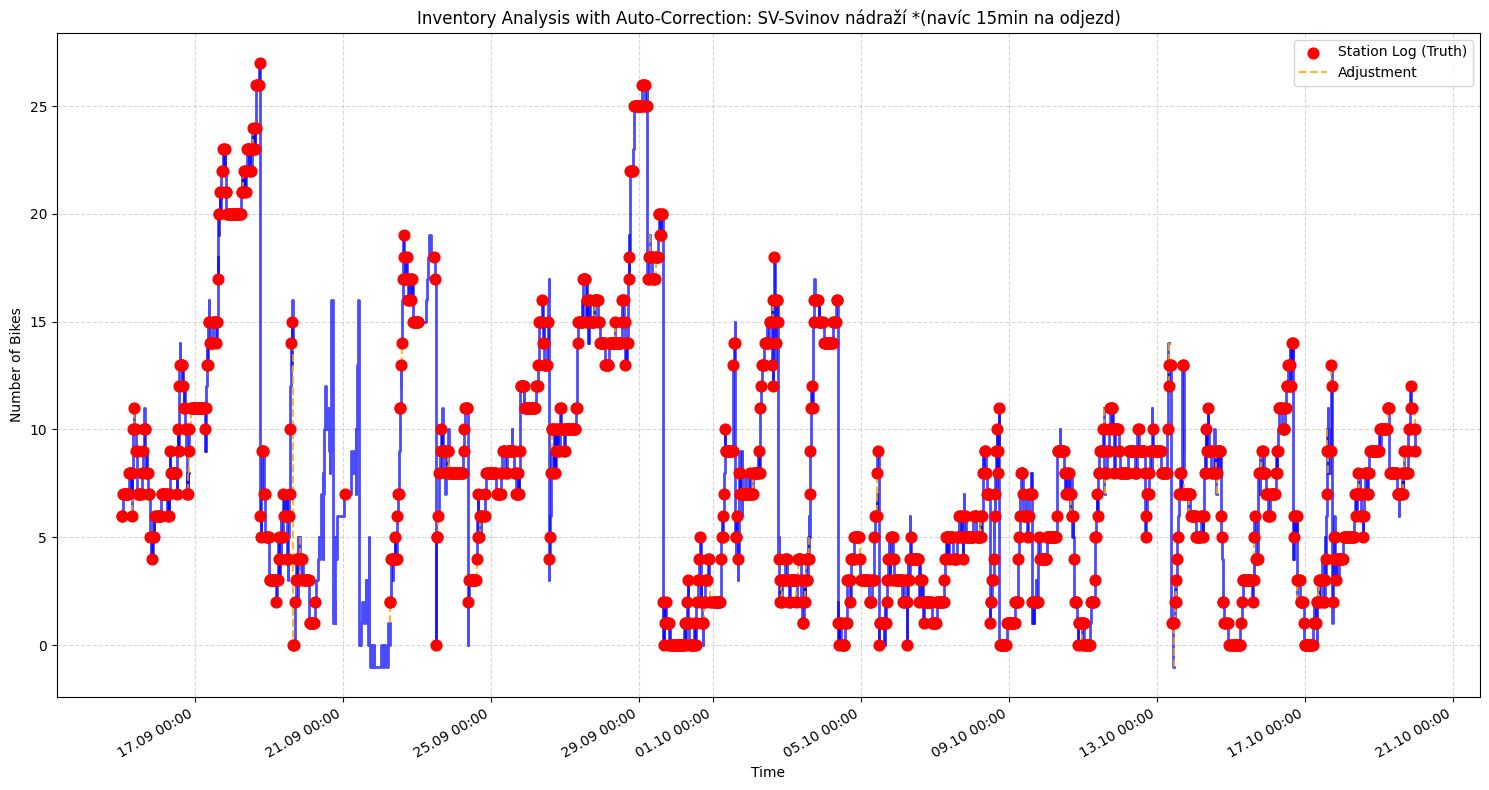

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# ==========================================
# CONFIGURATION SECTION
# ==========================================

RIDES_FILE_PATH = r'C:\Users\vaclavikmartin\PycharmProjects\Nextbike\data\nextbike_data_VSB_Vaclavik.xlsx'
LOGS_FILE_PATH = r'C:\Users\vaclavikmartin\PycharmProjects\Nextbike\data\nextbike_data_VSB_Vaclavik.xlsx'
REBALANCING_FILE_PATH = r'C:\Users\vaclavikmartin\PycharmProjects\Nextbike\data\nextbike_data_VSB_Vaclavik2.xlsx'

SHEET_RIDES = 'Vypujcky_Ostrava'
SHEET_LOGS = 'Stanice_Ostrava'
SHEET_REBALANCING = 'Ostrava'

TARGET_STATION = "SV-Svinov nádraží *(navíc 15min na odjezd)"
START_DATE_STR = "15.09.2025 0:00"
END_DATE_STR = "19.10.2025 23:59"
DATE_FORMAT = '%d.%m.%Y %H:%M'

# ==========================================
# ANALYSIS SCRIPT
# ==========================================

def run_analysis():
    print(f"--- Starting Analysis for {TARGET_STATION} ---")

    # 1. Load Data
    try:
        df_rides = pd.read_excel(RIDES_FILE_PATH, sheet_name=SHEET_RIDES)
        df_logs = pd.read_excel(LOGS_FILE_PATH, sheet_name=SHEET_LOGS)
        df_rebal = pd.read_excel(REBALANCING_FILE_PATH, sheet_name=SHEET_REBALANCING)
    except Exception as e:
        print(f"Error loading files: {e}")
        return

    # 2. Preprocess Dates and Filter
    analysis_start = datetime.strptime(START_DATE_STR, DATE_FORMAT)
    analysis_end = datetime.strptime(END_DATE_STR, DATE_FORMAT)

    # Clean dates
    df_rides['start_time'] = pd.to_datetime(df_rides['start_time'], format=DATE_FORMAT, errors='coerce')
    df_rides['end_time'] = pd.to_datetime(df_rides['end_time'], format=DATE_FORMAT, errors='coerce')

    time_col = 'Čas' if 'Čas' in df_logs.columns else df_logs.columns[0]
    df_logs[time_col] = pd.to_datetime(df_logs[time_col], format=DATE_FORMAT, errors='coerce')

    df_rebal['timestamp'] = pd.to_datetime(df_rebal['timestamp'], format=DATE_FORMAT, errors='coerce')

    # 3. Build All Movement Events
    events = []

    # Rides Out
    departures = df_rides[(df_rides['start_place'] == TARGET_STATION) &
                          (df_rides['start_time'] >= analysis_start) &
                          (df_rides['start_time'] <= analysis_end)]
    for _, row in departures.iterrows():
        events.append({'time': row['start_time'], 'change': -1, 'type': 'ride_out'})

    # Rides In
    arrivals = df_rides[(df_rides['end_place'] == TARGET_STATION) &
                        (df_rides['end_time'] >= analysis_start) &
                        (df_rides['end_time'] <= analysis_end)]
    for _, row in arrivals.iterrows():
        events.append({'time': row['end_time'], 'change': 1, 'type': 'ride_in'})

    # Rebalancing Out
    rebal_out = df_rebal[(df_rebal['from'] == TARGET_STATION) &
                         (df_rebal['timestamp'] >= analysis_start) &
                         (df_rebal['timestamp'] <= analysis_end)]
    for _, row in rebal_out.iterrows():
        qty = row['number_of_bikes'] if pd.notnull(row['number_of_bikes']) else 0
        events.append({'time': row['timestamp'], 'change': -qty, 'type': 'rebal_out'})

    # Rebalancing In
    rebal_in = df_rebal[(df_rebal['to'] == TARGET_STATION) &
                        (df_rebal['timestamp'] >= analysis_start) &
                        (df_rebal['timestamp'] <= analysis_end)]
    for _, row in rebal_in.iterrows():
        qty = row['number_of_bikes'] if pd.notnull(row['number_of_bikes']) else 0
        events.append({'time': row['timestamp'], 'change': qty, 'type': 'rebal_in'})

    df_events = pd.DataFrame(events)
    if not df_events.empty:
        df_events = df_events.sort_values('time')

    # 4. Prepare Logs
    if TARGET_STATION not in df_logs.columns:
        print(f"Error: Station '{TARGET_STATION}' not found in logs.")
        return

    station_logs = df_logs[[time_col, TARGET_STATION]].dropna().sort_values(time_col)
    station_logs = station_logs[(station_logs[time_col] >= analysis_start) &
                                (station_logs[time_col] <= analysis_end)]

    if station_logs.empty:
        print("No logs found in window.")
        return

    # 5. The "Checkpoint" Logic
    # We will iterate through intervals between logs (Log A -> Log B)

    final_plot_segments = []
    discrepancy_table = []

    # Iterate through each log entry
    for i in range(len(station_logs) - 1):
        # Define the interval
        start_log = station_logs.iloc[i]
        end_log = station_logs.iloc[i+1]

        t_start = start_log[time_col]
        count_start = start_log[TARGET_STATION]

        t_end = end_log[time_col]
        count_end_actual = end_log[TARGET_STATION]

        # Get events strictly inside this interval (after start, up to and including end)
        if df_events.empty:
            interval_events = pd.DataFrame()
        else:
            interval_events = df_events[(df_events['time'] > t_start) & (df_events['time'] <= t_end)].copy()

        # Calculate the path from Start Log
        if interval_events.empty:
            # Flat line
            calculated_end = count_start
            segment_df = pd.DataFrame({'time': [t_start, t_end], 'inventory': [count_start, count_start]})
        else:
            interval_events = interval_events.sort_values('time')
            interval_events['cumulative_change'] = interval_events['change'].cumsum()
            interval_events['inventory'] = count_start + interval_events['cumulative_change']

            # The last calculated value in this chain
            calculated_end = interval_events.iloc[-1]['inventory']

            # Prepare plotting data for this segment
            # Start point
            start_row = pd.DataFrame({'time': [t_start], 'inventory': [count_start]})
            # Events
            middle_rows = interval_events[['time', 'inventory']]
            # End point (projection before reset)
            end_row = pd.DataFrame({'time': [t_end], 'inventory': [calculated_end]})

            segment_df = pd.concat([start_row, middle_rows, end_row])

        final_plot_segments.append(segment_df)

        # CHECK DISCREPANCY
        diff = count_end_actual - calculated_end

        if diff != 0:
            discrepancy_table.append({
                'Log Timestamp': t_end,
                'Expected (Calculated)': int(calculated_end),
                'Actual (Log)': int(count_end_actual),
                'Adjustment Needed': int(diff),
                'Note': 'Missing Bikes' if diff < 0 else 'Surplus Bikes'
            })

    # 6. Output Table
    print("\n=== DISCREPANCY TABLE (Adjustments made at Log points) ===")
    if discrepancy_table:
        df_discrepancy = pd.DataFrame(discrepancy_table)
        print(df_discrepancy.to_string(index=False))
        # Optional: Save to CSV
        # df_discrepancy.to_csv('adjustments.csv', index=False)
    else:
        print("Perfect match! No adjustments were needed between logs.")

    # 7. Visualization
    plt.figure(figsize=(15, 8))

    # Plot segments
    # We plot each segment separately so we can see the "jumps" at the logs
    for segment in final_plot_segments:
        plt.step(segment['time'], segment['inventory'], where='post', color='blue', alpha=0.7, linewidth=2)

    # Plot Logs (The Red Dots)
    plt.scatter(station_logs[time_col], station_logs[TARGET_STATION],
                color='red', s=60, zorder=10, label='Station Log (Truth)')

    # Add vertical lines for adjustments
    for item in discrepancy_table:
        plt.vlines(x=item['Log Timestamp'],
                   ymin=item['Expected (Calculated)'],
                   ymax=item['Actual (Log)'],
                   color='orange', linestyle='--', alpha=0.8, label='Adjustment')

    # Deduplicate label for adjustment lines
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

    plt.title(f"Inventory Analysis with Auto-Correction: {TARGET_STATION}")
    plt.ylabel("Number of Bikes")
    plt.xlabel("Time")
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m %H:%M'))
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_analysis()